In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
raw_df = pd.read_csv('online_orders_fulfillment_raw.csv')
raw_df.head()

,order_number,order_date,delivery_date,quantity,customer_country,customer_state,product_category
0,366001,2016-01-01,2016-01-13,2,United States,California,Cameras and camcorders
1,366001,2016-01-01,2016-01-13,1,United States,California,Home Appliances
2,366002,2016-01-01,2016-01-12,7,Canada,Alberta,Cameras and camcorders
3,366002,2016-01-01,2016-01-12,1,Canada,Alberta,Computers
4,366002,2016-01-01,2016-01-12,4,Canada,Alberta,Cameras and camcorders


In [7]:
raw_df.info()
raw_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13165 entries, 0 to 13164
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_number      13165 non-null  int64 
 1   order_date        13165 non-null  object
 2   delivery_date     13165 non-null  object
 3   quantity          13165 non-null  int64 
 4   customer_country  13165 non-null  object
 5   customer_state    13165 non-null  object
 6   product_category  13165 non-null  object
dtypes: int64(2), object(5)
memory usage: 720.1+ KB


,order_number,quantity
count,1.316500e+04,13165.000000
mean,1.473162e+06,3.137942
std,4.377284e+05,2.250958
min,3.660010e+05,1.000000
25%,1.217013e+06,1.000000
50%,1.521011e+06,2.000000
75%,1.809004e+06,4.000000
max,2.243032e+06,10.000000


In [8]:
raw_df['delivery_date'] = pd.to_datetime(raw_df['delivery_date'])
raw_df['order_date'] = pd.to_datetime(raw_df['order_date'])

In [22]:
raw_df['delivery_lead_time'] = (raw_df['delivery_date'] - raw_df['order_date']).dt.days
raw_df.head()

,order_number,order_date,delivery_date,quantity,customer_country,customer_state,product_category,delivery_lead_time
0,366001,2016-01-01,2016-01-13,2,United States,California,Cameras and camcorders,12
1,366001,2016-01-01,2016-01-13,1,United States,California,Home Appliances,12
2,366002,2016-01-01,2016-01-12,7,Canada,Alberta,Cameras and camcorders,11
3,366002,2016-01-01,2016-01-12,1,Canada,Alberta,Computers,11
4,366002,2016-01-01,2016-01-12,4,Canada,Alberta,Cameras and camcorders,11


In [25]:
#Overall Average Delivery Lead Tim
overall_avg_lead_time = raw_df['delivery_lead_time'].mean()

#Total Quantity
total_quantity = raw_df['quantity'].sum()

#Slowest Category KPI
cat_group = raw_df.groupby('product_category')['delivery_lead_time'].mean().reset_index()
slowest_cat_row = cat_group.loc[cat_group['delivery_lead_time'].idxmax()]
kpi_slowest_cat = f"{slowest_cat_row['product_category']}, {slowest_cat_row['delivery_lead_time']:.2f}"

#Slowest Destination KPI
dest_group = raw_df.groupby(['customer_country', 'customer_state'])['delivery_lead_time'].mean().reset_index()
slowest_dest_row = dest_group.loc[dest_group['delivery_lead_time'].idxmax()]
kpi_slowest_dest = f"{slowest_dest_row['customer_country']}, {slowest_dest_row['customer_state']}, {slowest_dest_row['delivery_lead_time']:.2f}"

# Summary KPI DataFrame
kpi_df = pd.DataFrame({
    'KPI Metric': [
        'Overall Avg Delivery Lead Time', 
        'Total Quantity',
        'Slowest Category', 
        'Slowest Destination'   
    ],
    'Value': [
        round(overall_avg_lead_time,2),
        total_quantity,
        kpi_slowest_cat, 
        kpi_slowest_dest 
    ]
})

kpi_df

,KPI Metric,Value
0,Overall Avg Delivery Lead Time,4.53
1,Total Quantity,41311
2,Slowest Category,"TV and Video, 4.89"
3,Slowest Destination,"United Kingdom, Isle of Wight, 13.00"


In [26]:
#Fulfillment Velocity by Category
category_performance = (
    raw_df.groupby('product_category')['delivery_lead_time']
    .mean()
    .round(2)
    .reset_index(name='average_delivery_lead_time')
    .sort_values(by='average_delivery_lead_time', ascending=False)
)
category_performance

,product_category,average_delivery_lead_time
7,TV and Video,4.89
5,Home Appliances,4.77
6,"Music, Movies and Audio Books",4.59
1,Cameras and camcorders,4.56
0,Audio,4.53
4,Games and Toys,4.45
3,Computers,4.44
2,Cell phones,4.39


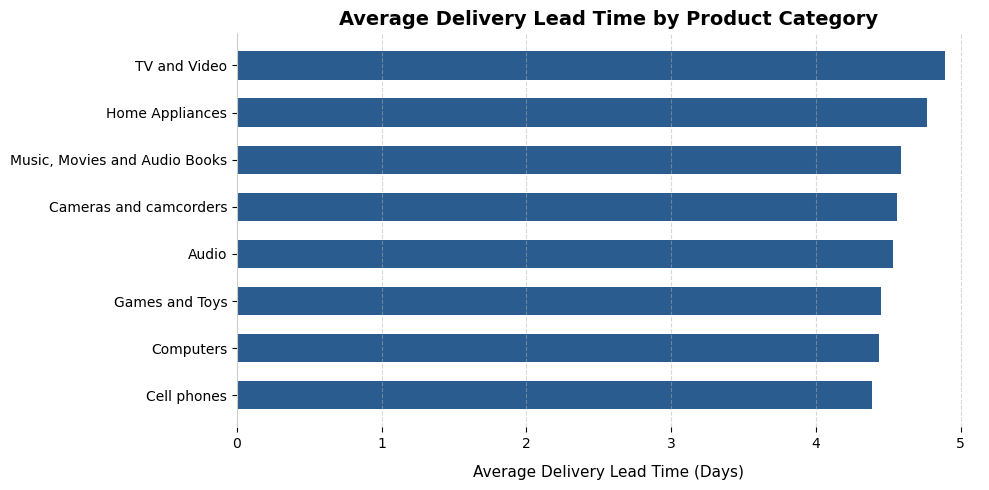

In [41]:
category_performance_rev = category_performance.sort_values(by='average_delivery_lead_time', ascending=True)

plt.figure(figsize=(10, 5))


plt.barh(
    y = category_performance_rev['product_category'], 
    width = category_performance_rev['average_delivery_lead_time'], 
    color = '#2b5c8f', 
    height = 0.6
)

# Titles and labels
plt.title('Average Delivery Lead Time by Product Category', fontsize=14, fontweight='bold', loc='center')
plt.xlabel('Average Delivery Lead Time (Days)', fontsize=11, labelpad=10)

# Clean up layout, borders, and gridlines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()

In [29]:
#Geographic Delivery Latency
geographic_delays = (
    raw_df.groupby(['customer_country','customer_state'])['delivery_lead_time']
    .mean()
    .round(2)
    .reset_index(name='average_delivery_lead_time')
    .sort_values(by='average_delivery_lead_time', ascending=False)
)
geographic_delays

,customer_country,customer_state,average_delivery_lead_time
221,United Kingdom,Isle of Wight,13.0
192,United Kingdom,East Dorset,11.0
267,United Kingdom,Reigate and Banstead,10.0
277,United Kingdom,Selby,10.0
21,France,Auvergne,9.0
...,...,...,...
306,United Kingdom,Telford and Wrekin,1.0
274,United Kingdom,Rushcliffe,1.0
327,United Kingdom,Winchester,1.0
153,United Kingdom,Bedford,1.0


In [30]:
#Volume vs. Speed Strain
quantity_impact = (
    raw_df.groupby('quantity')['delivery_lead_time']
    .mean()
    .round(2)
    .reset_index(name='average_delivery_lead_time')

)
quantity_impact

,quantity,average_delivery_lead_time
0,1,4.51
1,2,4.57
2,3,4.55
3,4,4.49
4,5,4.45
5,6,4.50
6,7,4.51
7,8,4.57
8,9,4.62
9,10,4.63


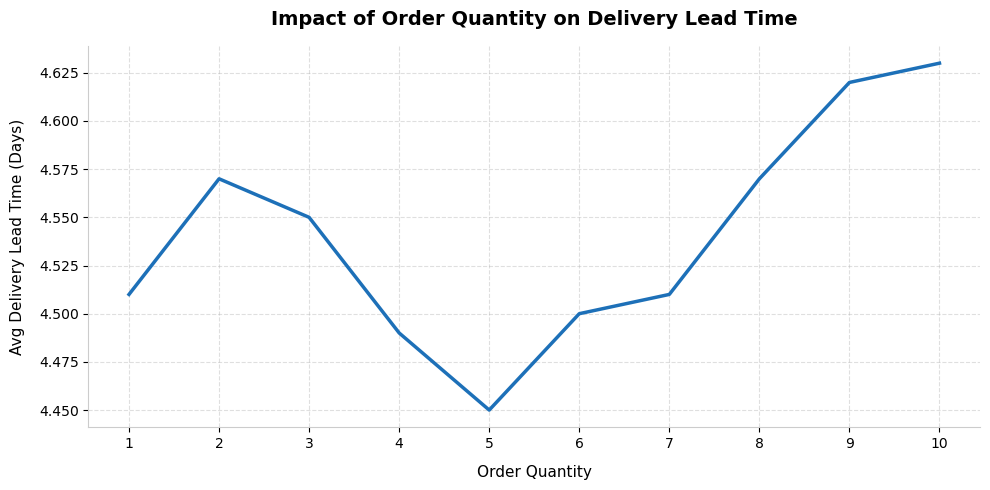

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    quantity_impact['quantity'], 
    quantity_impact['average_delivery_lead_time'], 
    color='#1d70b8', 
    linewidth=2.5, 
    markersize=6
)

# Titles and labels
plt.title('Impact of Order Quantity on Delivery Lead Time', fontsize=14, pad=15, fontweight='bold', loc='center')
plt.xlabel('Order Quantity', fontsize=11, labelpad=10)
plt.ylabel('Avg Delivery Lead Time (Days)', fontsize=11, labelpad=10)

# Clean up layout, borders, and gridlines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')
plt.grid(axis='both', linestyle='--', alpha=0.4)

plt.xticks(quantity_impact['quantity'])


plt.tight_layout()
plt.show()

In [43]:
file_name = 'online_fulfillment_summary_matrix.xlsx'

with pd.ExcelWriter(file_name) as writer:
    kpi_df.to_excel(writer, sheet_name='KPI_Summary', index=False)
    category_performance.to_excel(writer, sheet_name='Category_Performance', index=False)
    geographic_delays.to_excel(writer, sheet_name='Geographic_Delays', index=False)
    quantity_impact.to_excel(writer, sheet_name='Quantity_Impact', index=False)

print('Complete!')

Complete!
